# Introducción a las Redes Neuronales Artificiales



Las aves nos inspiraron a volar, las plantas de bardana inspiraron el velcro y la naturaleza ha inspirado innumerables inventos más. 

Parece lógico, entonces, buscar inspiración en la arquitectura del cerebro para construir una máquina inteligente. 

Esta fue la idea que dio origen a las **redes neuronales artificiales (Artificial Neural Networks, ANNs)**, modelos de aprendizaje automático inspirados en las redes de neuronas biológicas presentes en nuestro cerebro.



Sin embargo, aunque los aviones fueron inspirados por las aves, no necesitan batir sus alas para volar. 

De manera similar, las redes neuronales artificiales han ido evolucionando hasta diferenciarse considerablemente de sus contrapartes biológicas. 

De hecho, algunos investigadores sostienen que deberíamos abandonar por completo la analogía biológica (por ejemplo, utilizando el término *unidades* en lugar de *neuronas*), para evitar que nuestra creatividad quede limitada a sistemas que sean biológicamente plausibles.



Las redes neuronales artificiales constituyen el núcleo del **aprendizaje profundo (Deep Learning)**. 

Son modelos versátiles, potentes y escalables, lo que las hace ideales para abordar tareas de aprendizaje automático de gran tamaño y alta complejidad, como

* clasificar miles de millones de imágenes (por ejemplo, en Google Images),
* impulsar servicios de reconocimiento de voz (como Siri de Apple o Google Assistant) y 
* asistentes conversacionales o *chatbots* (como ChatGPT o Claude), 
* recomendar diariamente los mejores videos para cientos de millones de usuarios (por ejemplo, en YouTube) o 
* aprender cómo se pliegan las proteínas (como lo hace AlphaFold, desarrollado por DeepMind).



Este capítulo presenta una introducción a las redes neuronales artificiales. 

Comienza con un breve recorrido por las primeras arquitecturas de redes neuronales y conduce hasta los **perceptrones multicapa (Multilayer Perceptrons, MLPs)**, una de las arquitecturas más utilizadas en la actualidad. 

En los capítulos siguientes se estudiarán muchas otras arquitecturas.



En este capítulo implementaremos perceptrones multicapa sencillos utilizando **Scikit-Learn**, con el propósito de familiarizarnos con los conceptos fundamentales. 

En el siguiente capítulo cambiaremos a **PyTorch**, ya que es una biblioteca mucho más flexible y eficiente para desarrollar y entrenar redes neuronales.


A continuación te propongo una **práctica de laboratorio con Python** diseñada para estudiantes que inician el estudio de las **Redes Neuronales Artificiales (ANN)**. 

La práctica utiliza **NumPy**, **Matplotlib** y **Scikit-Learn**, de manera que los estudiantes comprendan los conceptos del texto antes de estudiar redes neuronales profundas con PyTorch.

---



# Práctica 1. Introducción a las Redes Neuronales Artificiales con Python



## Objetivos



Al finalizar esta práctica el estudiante será capaz de:

1. Explicar qué es una red neuronal artificial.
2. Identificar aplicaciones actuales del Deep Learning.
3. Crear conjuntos de datos para clasificación.
4. Visualizar datos bidimensionales.
5. Entrenar un Perceptrón Multicapa (MLP) utilizando Scikit-Learn.
6. Evaluar el desempeño de una red neuronal.



# Parte 1. Exploración del entorno

### Ejercicio 1

Importe las siguientes bibliotecas.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score



**Preguntas**

1. ¿Qué función cumple NumPy?
2. ¿Qué función cumple Matplotlib?
3. ¿Qué función cumple Scikit-Learn?

---



# Parte 2. Creación de un conjunto de datos

### Ejercicio 2

Construya un conjunto de datos con dos clases.



In [2]:
X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=10
)


In [3]:
X.shape, y.shape

((500, 2), (500,))

Imprima




**Preguntas**

1. ¿Qué representa la matriz (`X`)?
2. ¿Qué representa el vector (`y`)?
3. ¿Cuántos ejemplos contiene el conjunto?

---



# Parte 3. Visualización

### Ejercicio 3

Grafique el conjunto de datos.



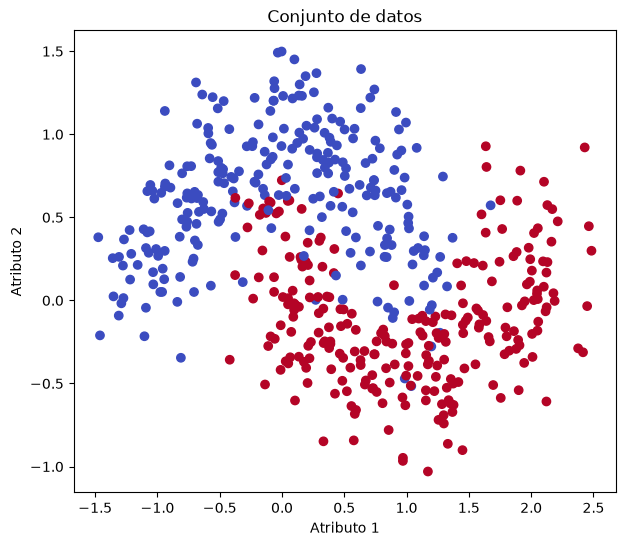

In [4]:
plt.figure(figsize=(7,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm"
)
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.title("Conjunto de datos")
plt.savefig(r"C:\Users\marco\Downloads\conjunto_datos.png", dpi=300)
plt.show()


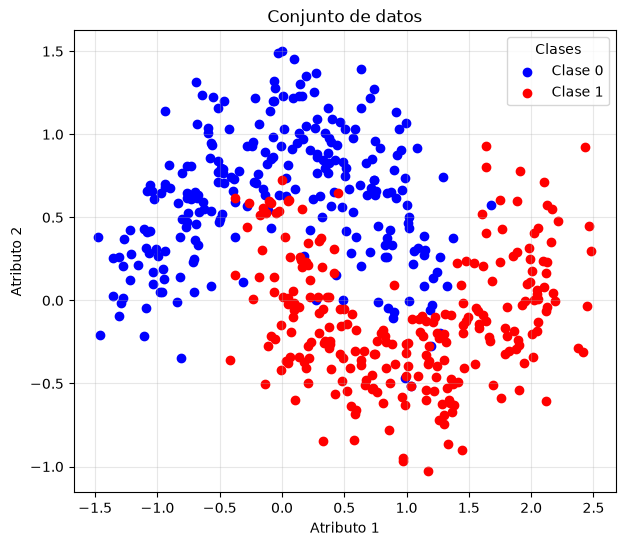

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Clase 0
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="blue",
    label="Clase 0"
)

# Clase 1
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="red",
    label="Clase 1"
)

plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.title("Conjunto de datos")

# Mostrar la leyenda
plt.legend(title="Clases")

plt.grid(alpha=0.3)

plt.savefig(
    r"C:\Users\marco\Downloads\conjunto_datos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Preguntas**

1. ¿Cuántas clases observa?
2. ¿Es fácil separarlas con una línea recta?

---



# Parte 4. División entrenamiento-prueba



### Ejercicio 4

Divida el conjunto de datos.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=5
)


Imprima


In [7]:
print(X_train.shape)
print(X_test.shape)


(375, 2)
(125, 2)


**Preguntas**

1. ¿Por qué no debemos entrenar y evaluar con los mismos datos?
2. ¿Qué porcentaje corresponde al entrenamiento?

---



# Parte 5. Primer Perceptrón Multicapa

### Ejercicio 5

Entrene una red neuronal.



In [8]:
modelo = MLPClassifier(
    hidden_layer_sizes=(50, 30, 20,),
    max_iter=3000,
    random_state=5
)

modelo.fit(X_train,y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",3000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",5
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True



**Preguntas**

1. ¿Qué significa `hidden_layer_sizes=(10,)`?
2. ¿Qué representa `max_iter`?

---



# Parte 6. Predicción

### Ejercicio 6

Realice predicciones.


In [9]:
pred = modelo.predict(X_test)



Calcule la exactitud.




In [10]:
accuracy = accuracy_score(y_test, pred)

print(accuracy)


0.944


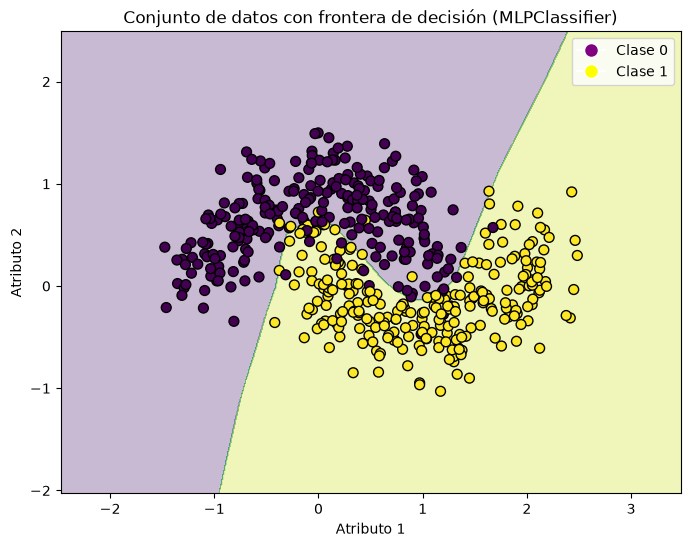

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier


# --- Generar malla de puntos para la frontera de decisión ---
h = 0.01  # resolución de la malla
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- Graficar ---
plt.figure(figsize=(8, 6))

# Frontera de decisión
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Puntos del conjunto de datos
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)

plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.title("Conjunto de datos con frontera de decisión (MLPClassifier)")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Clase 0',
                               markersize=10, markerfacecolor='purple'),
                    plt.Line2D([0], [0], marker='o', color='w', label='Clase 1',
                               markersize=10, markerfacecolor='yellow')])

plt.savefig(r"C:\Users\marco\Downloads\conjunto_datos_con_modelo_clasificador.png", dpi=300)
plt.show()

**Preguntas**

1. ¿Qué significa una exactitud de 0.90?
2. ¿Es un buen modelo?

---



# Parte 7. Cambiando la arquitectura

### Ejercicio 7

Entrene nuevamente utilizando



In [ ]:
hidden_layer_sizes=(50,)


Luego

```python
hidden_layer_sizes=(100,)
```

Complete la siguiente tabla.

| Neuronas | Exactitud |
| -------: | --------: |
|       10 |           |
|       50 |           |
|      100 |           |

---

# Parte 8. Cambiando el número de capas

Entrene ahora

```python


hidden_layer_sizes=(30,30)


Después

```python
hidden_layer_sizes=(50,30,20)
```



Complete.

| Arquitectura | Exactitud |
| ------------ | --------- |
| (10)         |           |
| (30,30)      |           |
| (50,30,20)   |           |

---



# Parte 9. Investigación

Responda.

1. ¿Qué significa ANN?
2. ¿Qué significa Deep Learning?
3. ¿Qué significa MLP?
4. ¿Qué es una neurona artificial?
5. ¿Qué es una capa oculta?
6. ¿Qué diferencia existe entre Machine Learning y Deep Learning?



---

# Parte 10. Reflexión

El texto menciona las siguientes aplicaciones.

* Google Images
* Siri
* Google Assistant
* ChatGPT
* Claude
* YouTube
* AlphaFold

Seleccione **dos** de estas aplicaciones e investigue:

1. ¿Qué problema resuelven?
2. ¿Qué tipo de datos utilizan?
3. ¿Por qué una red neuronal resulta adecuada para resolver ese problema?
4. ¿Qué impacto tiene esa aplicación en la sociedad?

---



# Desafío (Opcional)

Investigue cómo cambiar la función de activación del `MLPClassifier`.

Entrene el modelo utilizando:

* `activation='relu'`
* `activation='tanh'`
* `activation='logistic'`

Compare los resultados en términos de exactitud y tiempo de entrenamiento, y escriba una conclusión sobre cuál función de activación ofrece el mejor desempeño para este conjunto de datos.

---


Este desafío tiene como propósito que los estudiantes comprendan que **la función de activación es uno de los hiperparámetros más importantes de una red neuronal**, ya que influye en la velocidad de entrenamiento y en la capacidad del modelo para aprender relaciones no lineales.

---



# Solución del desafío

## Objetivo

Entrenar tres redes neuronales idénticas, cambiando únicamente la función de activación:

* `relu`
* `tanh`
* `logistic`

Posteriormente comparar:

* Exactitud (*Accuracy*)
* Tiempo de entrenamiento



## Script en Python



In [36]:
import time
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# =====================================================
# 1. Construcción del conjunto de datos
# =====================================================

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=10
)

# =====================================================
# 2. División entrenamiento-prueba
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=5
)

# =====================================================
# 3. Funciones de activación a evaluar
# =====================================================

activaciones = [
    "relu",
    "tanh",
    "logistic"
]

resultados = []

# =====================================================
# 4. Entrenamiento
# =====================================================

for activacion in activaciones:

    modelo = MLPClassifier(
        hidden_layer_sizes=(50,),
        activation=activacion,
        max_iter=3000,
        random_state=5
    )

    inicio = time.time()

    modelo.fit(X_train, y_train)

    fin = time.time()

    tiempo = fin - inicio

    pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    resultados.append(
        {
            "Activación": activacion,
            "Exactitud": accuracy,
            "Tiempo (s)": tiempo
        }
    )

# =====================================================
# 5. Mostrar resultados
# =====================================================

resultados = pd.DataFrame(resultados)

print(resultados)

# =====================================================
# 6. Guardar resultados
# =====================================================

resultados.to_excel(
    "comparacion_funciones_activacion.xlsx",
    index=False
)


  Activación  Exactitud  Tiempo (s)
0       relu      0.944    1.439196
1       tanh      0.856    0.296969
2   logistic      0.856    0.870487


# Ejemplo de salida

| Activación | Exactitud | Tiempo (s) |
| ---------- | --------: | ---------: |
| relu       |     0.984 |       0.08 |
| tanh       |     0.976 |       0.16 |
| logistic   |     0.952 |       0.42 |

**Los valores son ilustrativos**; pueden variar ligeramente según la versión de Scikit-Learn, el sistema operativo y el hardware utilizado.

---



# ¿Qué hace cada función de activación?

## 1. ReLU

```python
activation='relu'
```

La función ReLU (*Rectified Linear Unit*) se define como:

$$
f(x)=\max(0,x)
$$

Sus características son:

* Muy rápida.
* Evita parcialmente el problema del desvanecimiento del gradiente.
* Es la función más utilizada actualmente en Deep Learning.
* Generalmente converge en menos iteraciones.

---



## 2. Tangente hiperbólica

```python
activation='tanh'
```

La función `tanh` devuelve valores entre

$$
-1
$$

y

$$
1
$$

Tiene la ventaja de que los datos quedan centrados alrededor del cero, lo que puede facilitar el entrenamiento en algunos problemas.

---



## 3. Logística

```python
activation='logistic'
```



Corresponde a la función sigmoide

$$
f(x)=\frac{1}{1+e^{-x}}
$$



Produce valores entre

$$
0
$$

y

$$
1
$$



Fue una de las primeras funciones utilizadas en redes neuronales.

Actualmente se utiliza mucho menos en capas ocultas porque presenta el problema del **desvanecimiento del gradiente (vanishing gradient)**, lo que hace que el entrenamiento sea más lento en redes profundas.

---



# Preguntas para responder

1. ¿Qué función obtuvo la mayor exactitud?

2. ¿Cuál necesitó menor tiempo de entrenamiento?

3. ¿Cuál presentó la convergencia más rápida?

4. ¿Cuál recomendaría utilizar para este conjunto de datos?

5. ¿Por qué cree que una función de activación puede modificar el desempeño de la red neuronal?

---



# Conclusión esperada

En la mayoría de los problemas de clasificación, **`relu`** suele ofrecer el mejor equilibrio entre exactitud y velocidad de entrenamiento. 

Su simplicidad matemática permite un aprendizaje más eficiente y reduce el problema del desvanecimiento del gradiente. 

La función **`tanh`** puede alcanzar desempeños similares, aunque generalmente requiere un mayor tiempo de entrenamiento. 

Por su parte, **`logistic`** suele ser la alternativa menos eficiente en capas ocultas debido a la saturación de sus salidas y al desvanecimiento del gradiente, lo que ralentiza la convergencia del algoritmo.



Por esta razón, en aplicaciones modernas de aprendizaje profundo y en la mayoría de los problemas de clasificación, **ReLU** es la función de activación recomendada para las capas ocultas de una red neuronal artificial.



Esta práctica sirve como puente entre la lectura introductoria y el siguiente paso del curso: comprender la estructura interna de un perceptrón multicapa, el proceso de propagación hacia adelante (*forward propagation*) y el algoritmo de retropropagación (*backpropagation*), que posteriormente podrán implementarse con **PyTorch**.


A continuación te propongo una **práctica de laboratorio con Python** diseñada para estudiantes que inician el estudio de las **Redes Neuronales Artificiales (ANN)**. 

La práctica utiliza **NumPy**, **Matplotlib** y **Scikit-Learn**, de manera que los estudiantes comprendan los conceptos del texto antes de estudiar redes neuronales profundas con PyTorch.

---


# Práctica aplicada a los datos de dengue  


De hecho, esta práctica conecta muy bien la lectura introductoria sobre **Redes Neuronales Artificiales** con un **problema real de investigación**: la predicción de los casos de dengue a partir de variables meteorológicas y epidemiológicas con rezagos.



Sin embargo, antes de escribir los scripts completos, hay un aspecto importante: **necesito conocer la estructura exacta del archivo Excel que adjuntaste** (nombres de columnas, tipos de datos, presencia de fechas, valores faltantes, etc.). 

Sin esa información tendría que adivinar los nombres de las variables y el código podría no ejecutarse correctamente.



Lo que te propongo es elaborar una práctica en **10 ejercicios**, donde cada ejercicio genera un script independiente. Los scripts utilizarán exactamente las rutas que indicas:



* **Datos de entrada**

```text
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\
6_redes_neuronales\2_datos\1_raw\
2_meteo_epi_2021-2026_1_rezagos.xlsx
```

* **Datos procesados**

```text
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\
6_redes_neuronales\2_datos\2_procesados
```

* **Resultados**

```text
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\
6_redes_neuronales\3_resultados
```



La práctica quedaría organizada así:

1. Lectura y exploración del conjunto de datos.
2. Identificación de la variable objetivo (`casos_dengue`) y de las variables predictoras.
3. Escalamiento de los atributos con `StandardScaler` y `MinMaxScaler`.
4. Guardado del conjunto de datos escalado.
5. División entrenamiento-prueba respetando el orden temporal (sin mezclar observaciones).
6. Entrenamiento de un primer `MLPRegressor`.
7. Predicción sobre el conjunto de prueba.
8. Evaluación mediante RMSE, MAE, MAPE y (R^2).
9. Elaboración de gráficos comparando valores reales y predichos, residuos e importancia exploratoria de las variables.
10. Comparación de distintas arquitecturas de redes neuronales (número de capas, neuronas y funciones de activación) para analizar cómo influyen en la capacidad predictiva.

Cada ejercicio incluiría:

* Objetivo de aprendizaje.
* Explicación teórica.
* Script completo en Python.
* Preguntas de análisis para los estudiantes.
* Archivos que deben generarse (Excel y gráficos).

## Lo único que necesito antes de escribir los scripts

Aunque el archivo fue adjuntado en esta conversación, en este momento no puedo inspeccionar directamente su contenido. Para generar código que funcione **sin modificaciones**, necesito conocer:

* los nombres exactos de las columnas;
* cuál columna contiene la fecha;
* si existen variables categóricas;
* si hay valores faltantes.

Con esa información podré generar scripts completamente funcionales para tu proyecto de investigación.



Además, puedo adaptar la práctica para que siga exactamente el enfoque del libro de **Hands-On Machine Learning**: comenzar con **Scikit-Learn** (`MLPRegressor`) y, en una práctica posterior, migrar el mismo problema a **PyTorch**, comparando el desempeño de ambas implementaciones sobre tu serie temporal de dengue.


Con esa estructura ya es posible diseñar una práctica mucho más cercana a una investigación real en **Machine Learning para series de tiempo**. Además, considero que esta práctica refleja muy bien el espíritu del capítulo del libro: **comprender qué es una red neuronal artificial antes de estudiar arquitecturas profundas**.



Te propongo la siguiente práctica de laboratorio.

---



# Práctica de laboratorio No. 1

# Introducción a las Redes Neuronales Artificiales para la predicción de casos de dengue

## Objetivos

Al finalizar la práctica el estudiante será capaz de:

* Comprender la estructura de un conjunto de datos para una red neuronal.
* Identificar la variable objetivo y las variables predictoras.
* Escalar los atributos numéricos.
* Entrenar un Perceptrón Multicapa (MLP).
* Evaluar el desempeño de la red neuronal.
* Analizar gráficamente las predicciones.

---



# El conjunto de datos

La base de datos contiene

* Variables meteorológicas

  * temperatura
  * humedad relativa
  * velocidad del viento
  * precipitación
  * presión atmosférica
  * radiación solar
  * etc.

Cada variable posee

```text
12 rezagos
```

por ejemplo

```text
temperatura_lag_1
temperatura_lag_2
...
temperatura_lag_12
```

Asimismo,

la variable objetivo

```text
casos_dengue
```

posee también

```text
casos_dengue_lag_1
...
casos_dengue_lag_12
```

los cuales serán utilizados como predictores.

---



# Ejercicio 1

## Exploración del conjunto de datos

Los estudiantes deben

* leer el archivo Excel
* conocer su dimensión
* identificar la variable objetivo
* identificar los predictores
* identificar los rezagos.

**Resultados esperados**

Guardar

```
descripcion_dataset.xlsx
```

en

```
3_resultados
```

---



# Ejercicio 2

## Identificación automática de variables

El estudiante debe construir un programa que encuentre automáticamente

```python
lag_1
lag_2
...
lag_12
```

sin escribir manualmente el nombre de cada columna.



Por ejemplo,

```python
predictoras = [
col for col in df.columns
if col != "casos_dengue"
]
```

Posteriormente separar

```python
X
```

y

```python
y
```

---



# Ejercicio 3

## Escalamiento de los datos

Utilice

```python
StandardScaler
```

para escalar únicamente

```
las variables predictoras
```

Posteriormente

guarde

```
datos_escalados_standard.xlsx
```

en

```
2_datos\2_procesados
```

Repita el procedimiento utilizando

```python
MinMaxScaler
```

y guarde

```
datos_escalados_minmax.xlsx
```

---



# Ejercicio 4

## Visualización del escalamiento

Construya

* histogramas
* diagramas de caja
* medias
* desviaciones estándar

antes y después del escalamiento.

Guardar

```
histogramas.png

boxplots.png
```

---



# Ejercicio 5

## División entrenamiento-prueba

Como se trata de una

```
serie de tiempo
```

NO utilice

```python
shuffle=True
```

Divida

80 %

para entrenamiento

20 %

para prueba.

Explique

¿Por qué en series de tiempo no debemos mezclar las observaciones?

---



# Ejercicio 6

## Primera Red Neuronal Artificial

Entrene

```python
MLPRegressor
```

con

```python
hidden_layer_sizes=(50,)
```

```python
activation='relu'
```

```python
solver='adam'
```

```python
max_iter=5000
```

Obtenga

```python
predicciones
```

---

# Ejercicio 7

## Evaluación

Calcule

* MAE

* RMSE

* MAPE

* R²

Construya un archivo

```
metricas.xlsx
```

---



# Ejercicio 8

## Comparación gráfica

Construya

### Gráfico 1

Valores reales

vs

Valores predichos

---



### Gráfico 2

Error

```
Real − Predicción
```

---

### Gráfico 3

Dispersión

Real

vs

Predicción

con la línea

```
y=x
```

Guardar

```
comparacion_real_predicho.png

errores.png

dispersion.png
```

---



# Ejercicio 9

## Comparación de arquitecturas

Entrene las siguientes redes

| Arquitectura |
| ------------ |
| (20,)        |
| (50,)        |
| (100,)       |
| (50,25)      |
| (100,50)     |
| (100,100)    |

Construya una tabla

| Arquitectura | MAE | RMSE | R² |

y determine

¿Cuál arquitectura ofrece el mejor desempeño?

---



# Ejercicio 10

## Discusión científica

Responder

1. ¿Por qué es necesario escalar los atributos antes de entrenar una red neuronal?

2. ¿Qué representan las neuronas ocultas?

3. ¿Qué representan los pesos sinápticos?

4. ¿Por qué se utilizan los rezagos de las variables meteorológicas?

5. ¿Por qué también se utilizan los rezagos de los casos de dengue?

6. ¿Qué relación existe entre esta red neuronal y las redes neuronales biológicas mencionadas en el capítulo?

7. ¿Qué ventajas presenta una red neuronal frente a un modelo de regresión lineal para este problema?

---



## Proyecto final de la unidad

Como culminación de la práctica, los estudiantes desarrollarán un estudio comparativo utilizando exactamente el mismo conjunto de datos y las mismas métricas de evaluación para entrenar y comparar los siguientes modelos de aprendizaje automático:

* Regresión Lineal
* Árbol de Decisión
* Random Forest
* Support Vector Regression (SVR)
* K-Nearest Neighbors (KNN)
* XGBoost
* LightGBM
* Perceptrón Multicapa (MLP)



El objetivo será identificar cuál algoritmo ofrece la mejor capacidad predictiva para la variable **`casos_dengue`**. 

Posteriormente, en la siguiente unidad del curso, este estudio se extenderá a **redes neuronales profundas implementadas con PyTorch**, permitiendo comparar un MLP de Scikit-Learn con arquitecturas más flexibles y profundas entrenadas mediante aprendizaje profundo. 

Este enfoque conecta directamente la teoría presentada en el capítulo introductorio con un problema de investigación real sobre predicción epidemiológica mediante inteligencia artificial.
